In [1]:
import os
import sys
import faiss
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- 한글 폰트 적용을 위한 코드 ---------- #
from matplotlib import font_manager

root_dir = "/".join(os.getcwd().split("/")[:-1])
font_path = font_path = Path(root_dir).joinpath("data/NanumGothic-Regular.ttf")
font_name = font_manager.FontProperties(fname=font_path).get_name()
fontprop = font_manager.FontProperties(fname=font_path, size=12)
# ------------------------------------------ #

sys.path.append(os.path.abspath(".."))

from utils.dataset.config import DatasetPath
from utils.dataset.user_generator import generate_users
from utils.dataset.plot import show_items
from utils.model_ann.ann import build_index, search

# Dataset Path
- `recsys/data/dataset/` 하위 경로 생성

In [2]:
# 현재 Jupyter Notebook 실행 경로 (e.g., `documents/recsys/2_dataset`)
current_dir = os.path.abspath(os.curdir)

# `../recsys` 경로
base_dir = "/".join(current_dir.split("/")[:-1])

# 데이터셋 경로
dataset_dir = Path(base_dir).joinpath("data/dataset")

paths = DatasetPath(base_dir=dataset_dir, dataset_name="fashion")

# User Metadata
- 가상의 유저 데이터 생성

In [3]:
# 중앙값 근처로 많이 생성되는 삼각분포(기본)
df_user = generate_users(
    num_users=10000,
    age_range=(18, 60),
    genders=("M", "F"),
    gender_probs=(0.5, 0.5),
    seed=42,
)

# ---------- 피크 나이를 30세로 명시 ---------- #
# df_user_30peak = generate_users(
#     num_users=10000, age_range=(18, 70), age_mode=30, seed=42
# )

# ---------- 기존 균등분포로 생성하고 싶다면 ---------- #
# df_user_uniform = generate_users(
#     num_users=10000, age_range=(18, 70), age_distribution="uniform", seed=42
# )

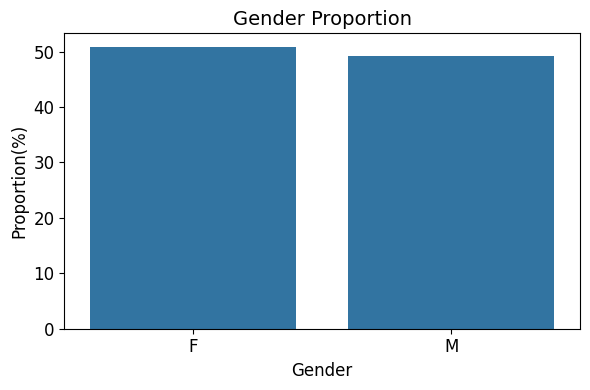

In [4]:
# 성별 분포
df_age_agg = df_user["gender"].value_counts(normalize=True).sort_index().reset_index()
df_age_agg["proportion"] = df_age_agg["proportion"] * 100

plt.figure(figsize=(6, 4), dpi=100)
sns.barplot(data=df_age_agg, x="gender", y="proportion")
plt.title("Gender Proportion", fontsize=14)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Proportion(%)", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

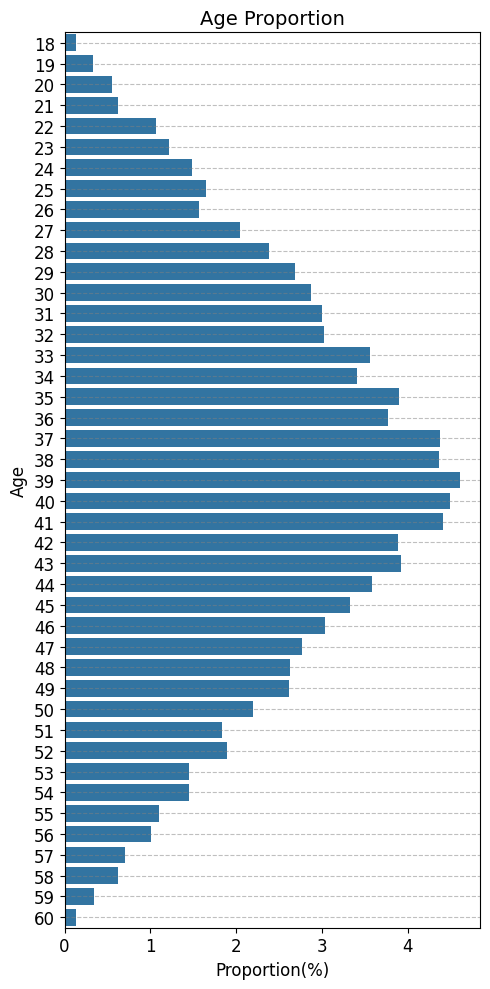

In [5]:
# 연령 분포
df_age_agg = df_user["age"].value_counts(normalize=True).sort_index().reset_index()
df_age_agg["age"] = df_age_agg["age"].astype(str)
df_age_agg["proportion"] = df_age_agg["proportion"] * 100

plt.figure(figsize=(5, 10), dpi=100)
sns.barplot(data=df_age_agg, x="proportion", y="age")
plt.title("Age Proportion", fontsize=14)
plt.xlabel("Proportion(%)", fontsize=12)
plt.ylabel("Age", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, axis="y", linestyle="--", color="grey", alpha=0.5)
plt.tight_layout()
plt.show()

In [6]:
df_user.to_parquet(paths.user_metadata_path)

# Item Metadata

In [7]:
df_item = pd.read_parquet(paths.item_metadata_path)
df_item = df_item.sort_values("item_id", ignore_index=True)

In [8]:
df_item.columns

Index(['item_id', 'name', 'brand_name', 'price', 'discount_price', 'gender',
       'age_group', 'base_color', 'season', 'year', 'usage', 'master_category',
       'sub_category', 'article_type', 'fit', 'occasion', 'description'],
      dtype='object')

In [9]:
columns = [
    "gender",
    "age_group",
    "season",
    "year",
    "usage",
    "master_category",
    "fit",
    "occasion",
]

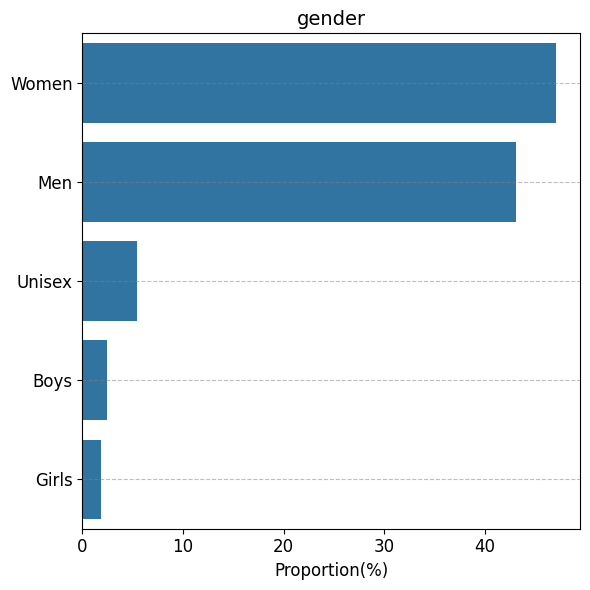

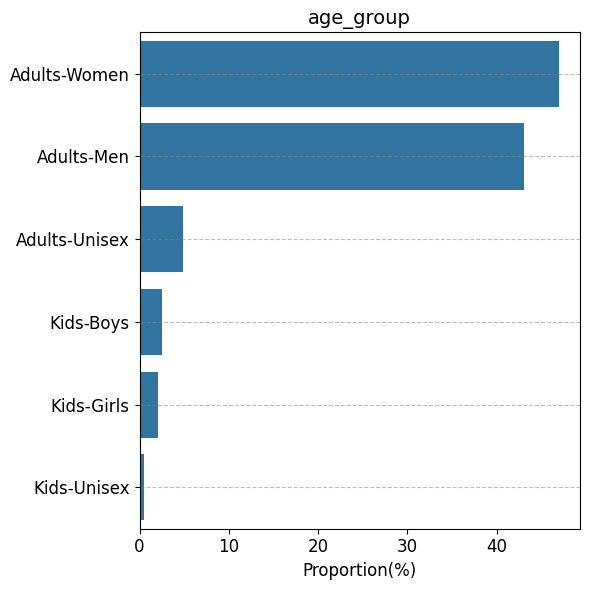

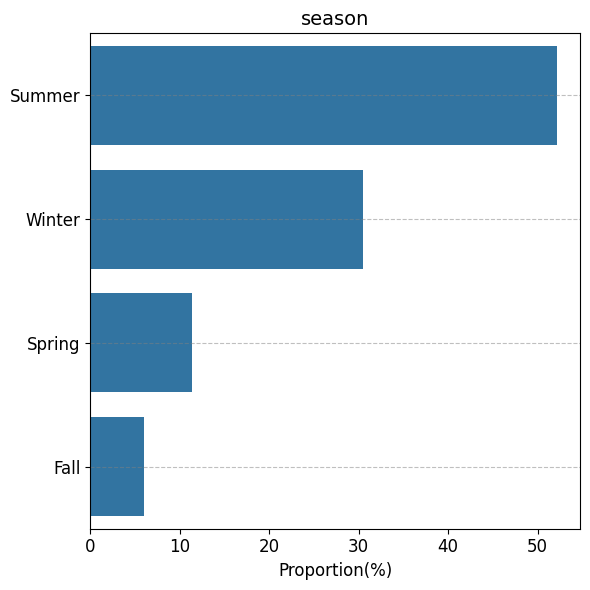

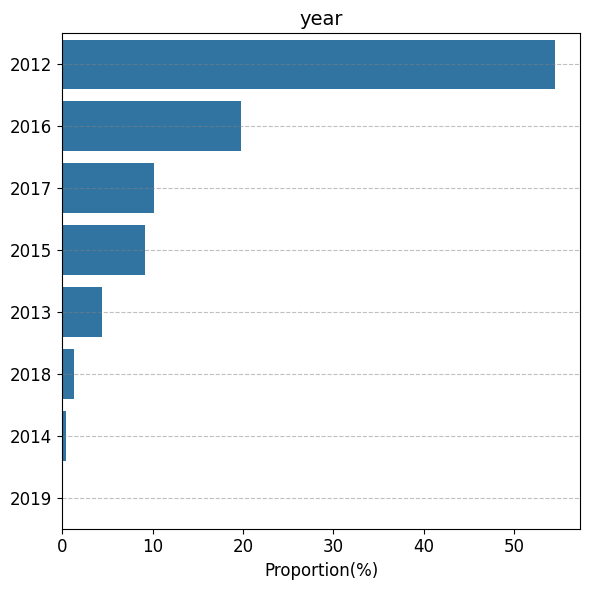

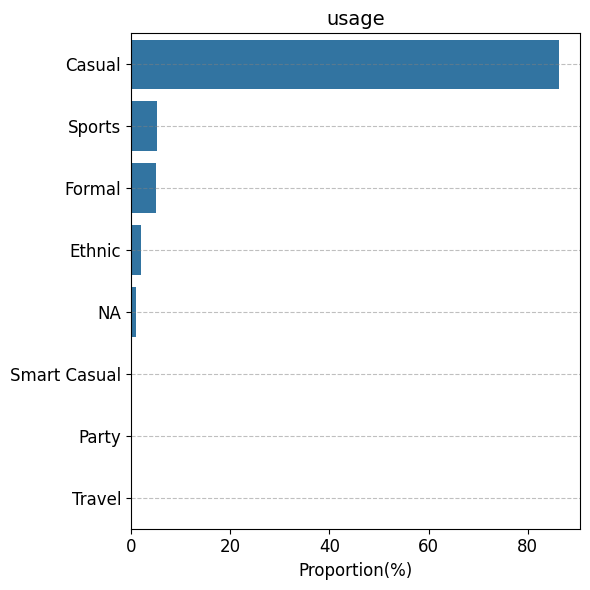

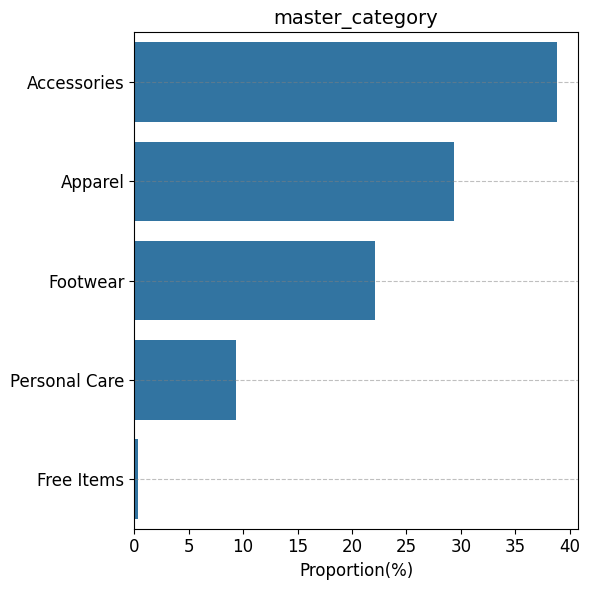

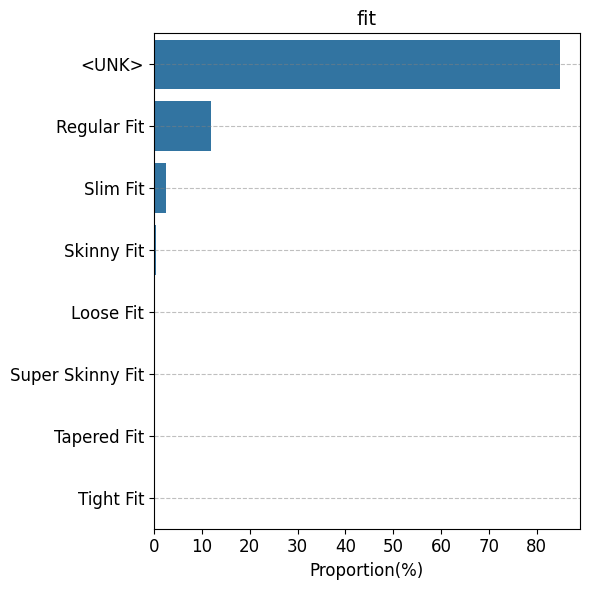

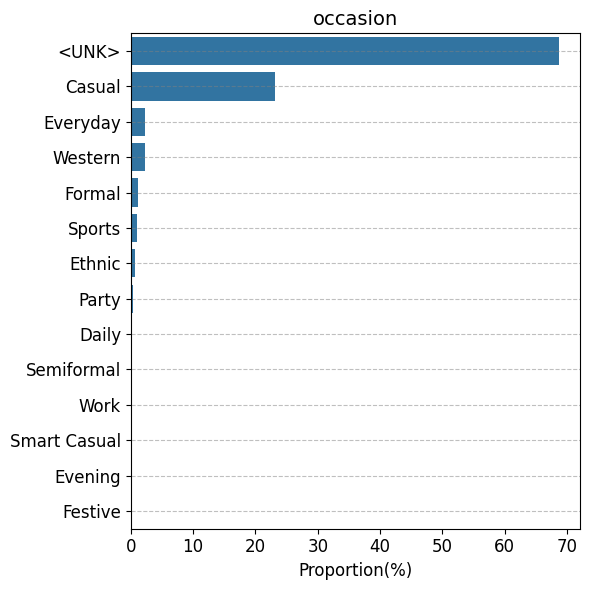

In [10]:
# 일부 데이터 분포 확인
for col in columns:
    # 필드별 비율 집계
    df_item[col].value_counts()
    df_agg = (
        df_item[col]
        .value_counts(normalize=True)
        .sort_values(ascending=False)
        .reset_index()
    )
    df_agg[col] = df_agg[col].astype(str)
    df_agg["proportion"] = df_agg["proportion"] * 100

    plt.figure(figsize=(6, 6), dpi=100)
    sns.barplot(data=df_agg, x="proportion", y=col)
    plt.title(f"{col}", fontsize=14)
    plt.xlabel("Proportion(%)", fontsize=12)
    plt.ylabel("")
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, axis="y", linestyle="--", color="grey", alpha=0.5)
    plt.tight_layout()
    plt.show()

# Item Vector

## Text Vector
- Vector Similarity Search 기반 추천을 위한 아이템 임베딩 벡터 생성

In [11]:
from sentence_transformers import SentenceTransformer

# -----------------------------------------------
# 텍스트 임베딩 모델 불러오기
# - "all-MiniLM-L6-v2": 소형 영문 문장 임베딩 모델
# - `normalize_embeddings=True`: 코사인 유사도를 위해 벡터를 정규화
# -----------------------------------------------
# model = SentenceTransformer("all-MiniLM-L6-v2")
model = SentenceTransformer("all-mpnet-base-v2")

# 아이템 제목을 벡터로 변환
text_vectors = model.encode(df_item["name"].tolist(), normalize_embeddings=True)
text_vectors = np.array(text_vectors).astype("float32")

# FAISS 인덱스 생성 (내적 기반 유사도)
dim = text_vectors.shape[1]
print(f"임베딩 차원: {dim}")
text_index = faiss.IndexFlatIP(dim)  # Inner Product (코사인 유사도용)
text_index.add(text_vectors)

item_id_map = {i: item_id for i, item_id in enumerate(df_item["item_id"].tolist())}

임베딩 차원: 768


In [12]:
# ANN 빌드
text_index = build_index(vectors=text_vectors)

In [13]:
# 벡터 유사도 검색
query_text = "white t-shirt"
query_vector = model.encode([query_text], normalize_embeddings=True).astype("float32")
result = search(index=text_index, query_vector=query_vector, top_k=5)
print(result)

[{1161: 0.7678297162055969, 4973: 0.7550424337387085, 7915: 0.7550424337387085, 5425: 0.7349002957344055, 6726: 0.7333637475967407}]


In [14]:
# 유사 상품 조회
for rnk, (item_idx, score) in enumerate(result[0].items()):
    item_id = item_id_map[item_idx]
    item_name = df_item[df_item["item_id"] == item_id]["name"].item()
    print(f"{rnk+1}. {item_name} (score: {score:.4f})")

1. Basics Men White T-shirt (score: 0.7678)
2. Myntra Men White T-shirt (score: 0.7550)
3. Myntra Men White T-shirt (score: 0.7550)
4. Proline Men White Polo T-Shirt (score: 0.7349)
5. Reebok Men Star White Polo T-shirt (score: 0.7334)


## Image Vector
- Vector Similarity Search 기반 추천을 위한 아이템 임베딩 벡터 생성

In [15]:
# ===================================================================
# 이미지 벡터 생성은 구글 코랩(Colab) GPU를 사용하여 실행
# ===================================================================

# import os
# import numpy as np
# import pandas as pd
# from tqdm import tqdm
#
# import torch
# from PIL import Image
# from transformers import CLIPProcessor, CLIPModel
#
#
# # -----------------------------------------------
# # 이미지 경로 설정
# # -----------------------------------------------
# from google.colab import drive
#
# drive.mount("/content/drive", force_remount=True)
#
# image_dir = "/content/drive/MyDrive/recsys/dataset/fashion/images"
#
# image_paths = [
#     os.path.join(image_dir, f)
#     for f in os.listdir(image_dir)
#     if f.lower().endswith(".jpg")
# ]
# print(f"[INFO] 총 이미지 수: {len(image_paths)}")
#
#
# # -----------------------------------------------
# # 모델 로드
# # -----------------------------------------------
# device = "cuda" if torch.cuda.is_available() else "cpu"
# print(f"[INFO] Using device: {device}")
#
# model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14").to(device)
# processor = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")
#
#
# def encode_images(image_paths, batch_size=128):
#     all_embeddings = []
#     all_filenames = []
#     for i in tqdm(range(0, len(image_paths), batch_size)):
#         batch_paths = image_paths[i : i + batch_size]
#         batch_images = []
#         valid_paths = []
#         for p in batch_paths:
#             try:
#                 img = Image.open(p).convert("RGB")
#                 batch_images.append(img)
#                 valid_paths.append(p)
#             except Exception as e:
#                 print(f"[WARN] Failed to load {p}: {e}")
#
#         if not batch_images:
#             continue
#
#         inputs = processor(images=batch_images, return_tensors="pt", padding=True).to(
#             device
#         )
#
#         with torch.no_grad():
#             outputs = model.get_image_features(**inputs)
#             embeddings = outputs / outputs.norm(dim=-1, keepdim=True)  # L2 정규화
#             embeddings = embeddings.cpu().numpy()
#
#         all_embeddings.append(embeddings)
#         all_filenames.extend(valid_paths)
#
#     return np.vstack(all_embeddings).astype("float32"), all_filenames
#
#
# # -----------------------------------------------
# # 임베딩 벡터 추출 및 저장
# # -----------------------------------------------
# embeddings, valid_paths = encode_images(image_paths, batch_size=256)
# df_image_vectors = pd.DataFrame(
#     {
#         "item_id": [int(x.split("/")[-1].replace(".jpg", "")) for x in valid_paths],
#         "image_vector": embeddings.tolist(),
#     }
# )
#
# output_path = "/content/drive/MyDrive/recsys/dataset/fashion/image_vectors.parquet"
# df_image_vectors.to_parquet(output_path)

In [16]:
# -----------------------------------------------
# 구글 코랩(Colab)에서 실행하여 완성된 파일을 다운로드 후 로드
# (파일을 미리 제공하므로 별도 실행 불필요)
# -----------------------------------------------
df_image_vectors = pd.read_parquet(paths.image_vectors_path)
df_image_vectors = df_image_vectors.sort_values("item_id", ignore_index=True)
item_id_map = {
    i: item_id for i, item_id in enumerate(df_image_vectors["item_id"].tolist())
}
image_vectors = np.array(df_image_vectors["image_vector"].tolist())

In [17]:
image_index = build_index(image_vectors)

In [18]:
image_dir = dataset_dir.joinpath("fashion/images")

[입력 이미지]: Wildcraft Zoomer Green Backpack)


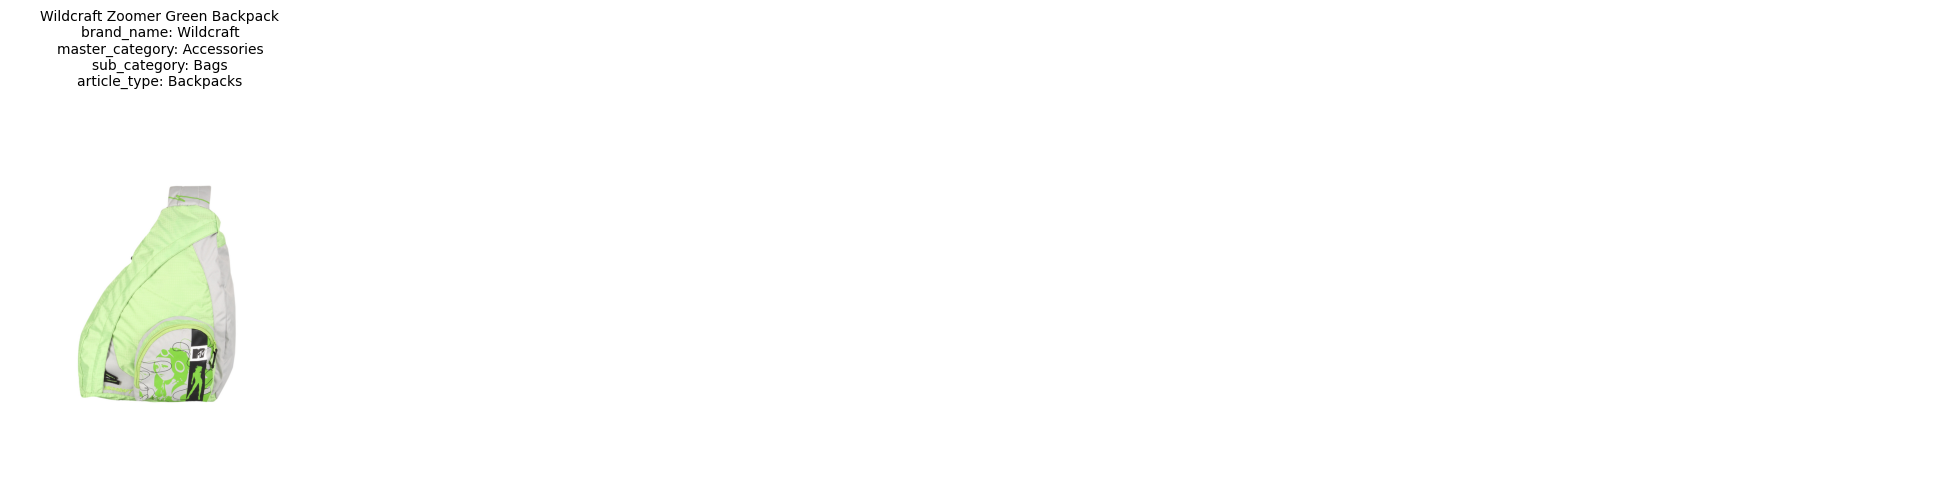

In [22]:
idx = 1

item_id = df_image_vectors.iloc[idx]["item_id"].item()
query_vector = df_image_vectors.iloc[idx]["image_vector"].reshape(1, -1)
print(f"[입력 이미지]: {df_item[df_item['item_id'] == item_id]['name'].values[0]})")
show_items(item_ids=[item_id], df_item=df_item, image_dir=image_dir)

In [23]:
result = search(index=image_index, query_vector=query_vector, top_k=5)
print(result)

[{1: 1.0000001192092896, 1958: 0.8190449476242065, 820: 0.8082550168037415, 5149: 0.7763245105743408, 9385: 0.7728490829467773}]


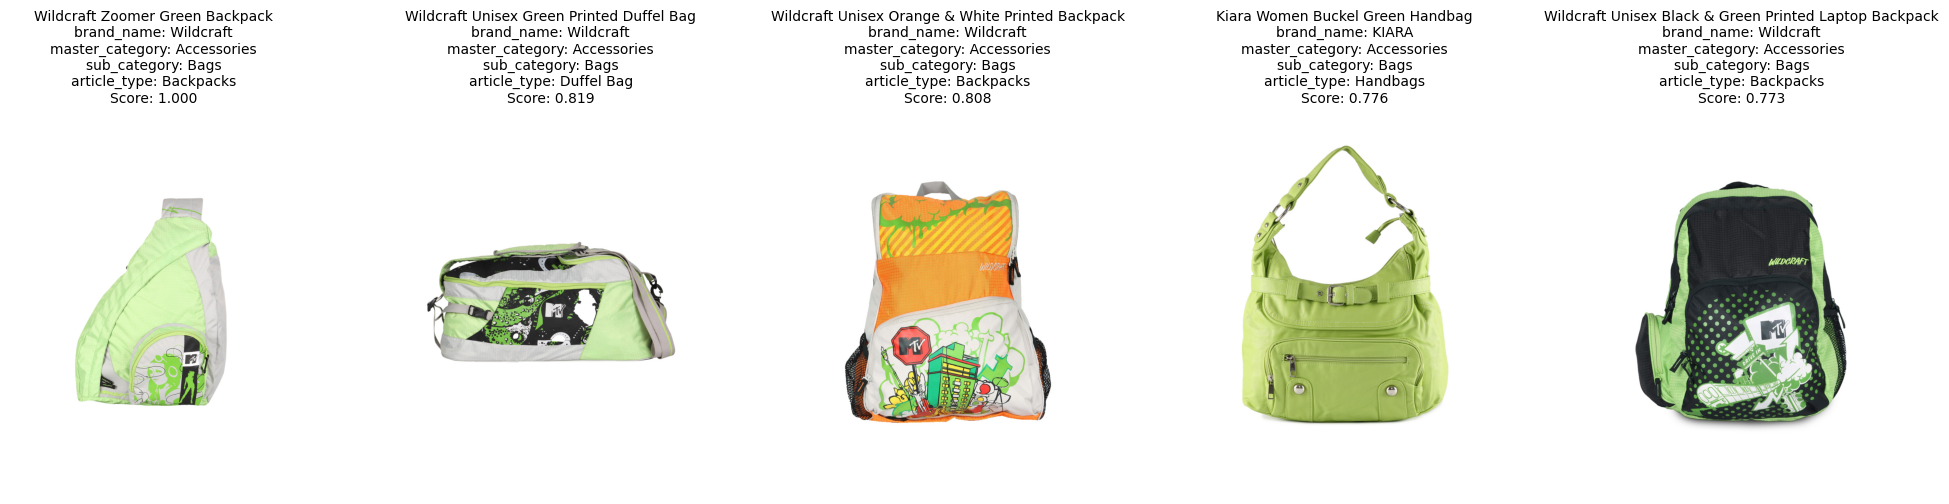

In [24]:
item_ids = [item_id_map[item_idx] for item_idx in result[0].keys()]
show_items(
    df_item=df_item,
    item_ids=item_ids,
    image_dir=image_dir,
    scores=list(result[0].values()),
)